In [10]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final Project/tweet_emotions.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Basic EDA


(40000, 3)
tweet_id      int64
sentiment    object
content      object
dtype: object
     tweet_id   sentiment                                            content
0  1956967341       empty  @tiffanylue i know  i was listenin to bad habi...
1  1956967666     sadness  Layin n bed with a headache  ughhhh...waitin o...
2  1956967696     sadness                Funeral ceremony...gloomy friday...
3  1956967789  enthusiasm               wants to hang out with friends SOON!
4  1956968416     neutral  @dannycastillo We want to trade with someone w...

Missing values:
 tweet_id     0
sentiment    0
content      0
dtype: int64

Sentiment counts:
 sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


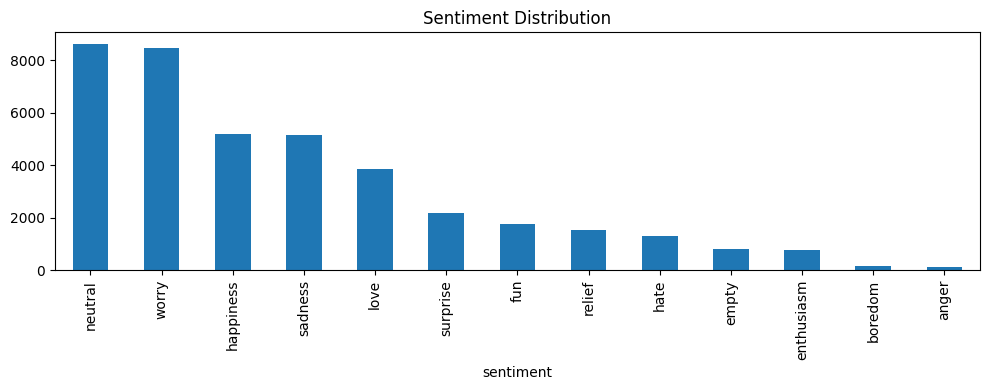

In [11]:
# Basic info
print(df.shape)
print(df.dtypes)
print(df.head())

# Check for nulls
print("\nMissing values:\n", df.isnull().sum())

# Sentiment distribution
print("\nSentiment counts:\n", df['sentiment'].value_counts())

# Visualize sentiment distribution
import matplotlib.pyplot as plt
df['sentiment'].value_counts().plot(kind='bar', figsize=(10,4), title='Sentiment Distribution')
plt.tight_layout()
plt.show()

# Cleaning

In [12]:
# Drop tweet_id (not needed for modeling)
df = df.drop(columns=['tweet_id'])

# Reset index
df = df.reset_index(drop=True)

print(df.shape)

(40000, 2)


# Text Preprocessing

In [13]:
import re

# 1) Lowercase
# 2) Remove @mentions
# 3) Remove URLS
# 4) Remove Punctuation/Numbers
# 5) Remove Extra Whitespace
def clean_text(text):
    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_content'] = df['content'].apply(clean_text)

print(df[['content', 'clean_content']].head())

                                             content  \
0  @tiffanylue i know  i was listenin to bad habi...   
1  Layin n bed with a headache  ughhhh...waitin o...   
2                Funeral ceremony...gloomy friday...   
3               wants to hang out with friends SOON!   
4  @dannycastillo We want to trade with someone w...   

                                       clean_content  
0  i know i was listenin to bad habit earlier and...  
1  layin n bed with a headache ughhhhwaitin on yo...  
2                      funeral ceremonygloomy friday  
3                wants to hang out with friends soon  
4  we want to trade with someone who has houston ...  


# Evaluating "Empty" Emotion

In [15]:
from IPython.display import HTML

empty_tweets = df[df['sentiment'] == 'empty']['content'].head(20).reset_index(drop=True)

HTML(empty_tweets.to_frame().style
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'normal',
        'max-width': '600px'
    })
    .set_table_styles([{
        'selector': 'td',
        'props': [('max-width', '600px'), ('word-wrap', 'break-word')]
    }])
    .to_html()
)

,content
0,@tiffanylue i know i was listenin to bad habit earlier and i started freakin at his part =[
1,@creyes middle school and elem. High schools will remain open for those who need credits to graduate. Cali is broken
2,@djmicdamn hey yu lil fucker i textd yu
3,@softtouchme just answered you- never learned how to write in French- just basic stuff-
4,Have a headache I'm going to bed. Goodnight!
5,@DymeDiva23 Nite. Now I'm up n bored as opposed to almost sleep frm b 4
6,"@TheTombert i was watching Harpers Island, lol... there was no vodka involved"
7,@tarng Trudy's off Burnet...the one up north that no one goes to
8,@msz_rockstar umm how bout em?..aint get 2 see da game but i see dey survived anotha game of da series due to notin but Lebron im guessin
9,I need to be sleeping.. But i'm not even tired..


In [17]:
## We decided to drop the empty label as they seem to be mostly untrustworthy or the combination of multiple emotions
df = df[df['sentiment'] != 'empty']

# Consolidating Emotions

In [18]:
emotion_mapping = {
    'happiness':   'happy',
    'fun':         'happy',
    'enthusiasm':  'happy',
    'love':        'happy',
    'relief':      'happy',
    'sadness':     'sad',
    'boredom':     'sad',
    'anger':       'angry',
    'hate':        'angry',
    'worry':       'fearful',
    'surprise':    'surprised',
    'neutral':     'neutral',
}

df['sentiment'] = df['sentiment'].map(emotion_mapping)

print(df['sentiment'].value_counts())

sentiment
happy        13112
neutral       8638
fearful       8459
sad           5344
surprised     2187
angry         1433
Name: count, dtype: int64


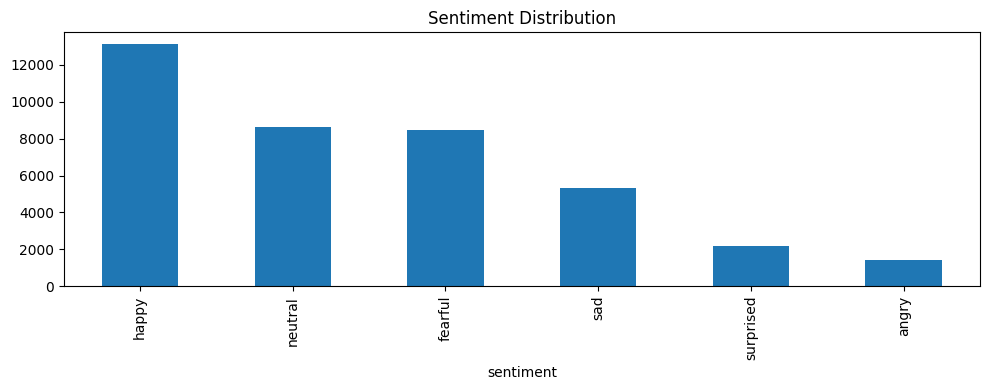

In [19]:
# Visualize sentiment distribution
import matplotlib.pyplot as plt
df['sentiment'].value_counts().plot(kind='bar', figsize=(10,4), title='Sentiment Distribution')
plt.tight_layout()
plt.show()

In [20]:
# Class Imbalance Decision
# The dataset shows imbalance across sentiment classes (happy: 13,112 vs angry: 1,433).
# We are choosing NOT to downsample the data because doing so would require dropping
# ~31,000 rows, resulting in significant loss of training data. Instead, we will use
# class_weight='balanced' at model training time, which mathematically adjusts the
# weight each class contributes to the loss function — achieving the same correction
# without discarding any data.

# Encode Labels

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", mapping)

Label mapping: {'angry': np.int64(0), 'fearful': np.int64(1), 'happy': np.int64(2), 'neutral': np.int64(3), 'sad': np.int64(4), 'surprised': np.int64(5)}


# Train/Test Split

In [22]:
from sklearn.model_selection import train_test_split

X = df['clean_content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 31338, Test: 7835


# Vectorize with TF-IDF

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (31338, 10000)
Test shape: (7835, 10000)


# Train Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)
print("Training complete.")

Training complete.


# Evaluate Logistic Regression

              precision    recall  f1-score   support

       angry       0.18      0.42      0.26       287
     fearful       0.38      0.30      0.34      1692
       happy       0.65      0.51      0.58      2622
     neutral       0.39      0.39      0.39      1728
         sad       0.31      0.35      0.33      1069
   surprised       0.11      0.22      0.15       437

    accuracy                           0.40      7835
   macro avg       0.34      0.37      0.34      7835
weighted avg       0.44      0.40      0.41      7835



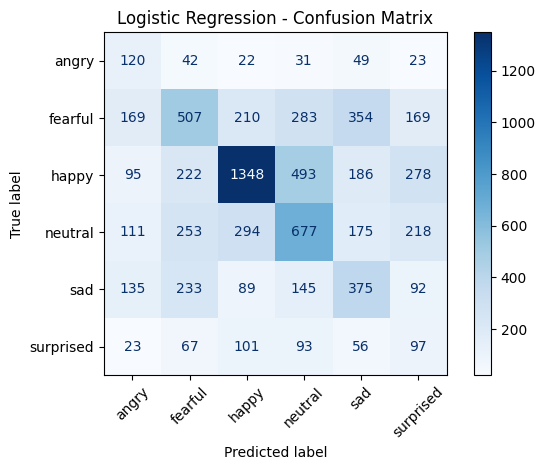

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = lr_model.predict(X_test_tfidf)

# Classification report
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import accuracy_score
baseline_accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline Accuracy: 0.3987
